# Chapter 3 — Framework 2: Anchor-partition consensus concordance across taxa and environmental space

This notebook reorganizes the concordance analysis into the same narrative structure as Framework 1, with reusable tools isolated in a dedicated Definition Corner.

The execution structure is:

```text
Inputs → Analysis parameters → Definition Corner → Process → Outputs → Visualization
```

The workflow begins with the finalized A3 anchor partition, builds taxa-space and environmental-space consensus co-assignment matrices across the anchor sites, converts those consensus matrices into per-site concordance margins, and then visualizes how taxa and environmental support agree or conflict for each anchor site.

# Inputs

Load site metadata, the taxa and environmental matrices, and the A3 final cluster-label artifact that provides the anchor partition for the concordance analysis.

In [60]:
from pathlib import Path
import pandas as pd

STUDY_CASE = "DR"
SITE_ID_COLUMN = "Integrated Code"

if STUDY_CASE == "DR":
    STUDY_CASE_LABEL = "Detroit River case study"
    CASE_ROOT_DIR = Path("../DetroitRiverCase")
else:
    STUDY_CASE_LABEL = "Corridor case study"
    CASE_ROOT_DIR = Path("..")

METADATA_DIR = CASE_ROOT_DIR / "data"
ARTIFACT_DIR = CASE_ROOT_DIR / "artifacts"
RESULTS_DIR = CASE_ROOT_DIR / "results"
FIGURE_DIR = CASE_ROOT_DIR / "figures"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load site sampling information
site_info = pd.read_excel(METADATA_DIR / "Info.xlsx")
site_ids = site_info[SITE_ID_COLUMN].reset_index(drop=True).rename(SITE_ID_COLUMN)

# Load the taxa matrix T and merge with site IDs
T = pd.read_excel(METADATA_DIR / "T.xlsx").reset_index(drop=True)
T_with_site_id = pd.concat([site_ids, T], axis=1)

# Load the Environmental matrix E and merge with site IDs
E = pd.read_excel(METADATA_DIR / "E.xlsx").reset_index(drop=True)
E_with_site_id = pd.concat([site_ids, E], axis=1)

# Load the A3 final cluster label table
A3 = pd.read_excel(ARTIFACT_DIR / "A3_final_cluster_labels.xlsx").reset_index(drop=True)

print(f"Study case: {STUDY_CASE_LABEL}")
print(f"Loaded taxa matrix T: {T_with_site_id.shape[0]} sites x {T_with_site_id.shape[1] - 1} taxa variables")
display(T_with_site_id.head())
print(f"Loaded environmental matrix E: {E_with_site_id.shape[0]} sites x {E_with_site_id.shape[1] - 1} environmental variables")
display(E_with_site_id.head())
print(f"Loaded A3 final cluster label table: {A3.shape[0]} sites")
display(A3.head())

Study case: Detroit River case study
Loaded taxa matrix T: 213 sites x 16 taxa variables


,Integrated Code,Oligochaeta,Nematoda,Chironomidae,Ceratopogonidae,Hexagenia,Caenis,Hydropsychidae,Other Trichoptera,Amphipoda,Dreissena,Acari,Hydrozoa,Hirudinea,Turbellaria,Gastropoda,Sphaeriidae
0,DR-02,2.269984,0.563546,1.655598,0.0,0.309116,0.000000,2.438439,0.0,4.529993,6.082918,0.000000,0.00000,0.00000,0.0,0.000000,0.0
1,DR-03,3.808504,3.512091,6.242625,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.801982,0.801982,0.00000,0.00000,0.0,0.456015,0.0
2,DR-04,4.820163,5.519382,4.733464,0.0,0.815949,0.000000,0.000000,0.0,0.000000,0.172158,1.010022,0.00000,0.00000,0.0,0.464907,0.0
3,DR-06,1.449187,0.181596,2.271083,0.0,0.999573,0.033941,0.000000,0.0,1.840242,6.475708,0.000000,1.82093,0.23027,0.0,0.000000,0.0
4,DR-07,1.082238,0.246371,2.499653,0.0,0.128438,0.000000,0.128438,0.0,4.224262,6.266368,0.000000,0.00000,0.00000,0.0,0.246371,0.0


Loaded environmental matrix E: 213 sites x 6 environmental variables


,Integrated Code,LOI (%),Measured Depth (m),Temperature (oC),Water DO Bottom (mg/L),MPS (Phi),Velocity at bottom (m/sec)
0,DR-02,1.140000,5.9436,15.0,9.8,0.555556,0.37186
1,DR-03,0.780000,3.2004,15.5,10.6,0.566667,0.44179
2,DR-04,0.530000,1.2192,17.0,9.0,0.642857,0.08216
3,DR-06,4.173333,8.0772,16.0,9.3,2.238095,0.14675
4,DR-07,0.820000,2.1336,16.0,12.5,0.647059,0.18312


Loaded A3 final cluster label table: 25 sites


,Integrated Code,Cluster Label
0,DR-103,C1
1,DR-144,C2
2,DR-25,C2
3,DR-145,C2
4,DR-143,C2


## Analysis parameters

These parameters control the A3 anchor partition, the taxa dissimilarity workflow, the selected environmental descriptors, the fixed cluster count used in the consensus calculations, and the bootstrap depth.

In [61]:
SITE_ID_COLUMN = "Integrated Code"
CLUSTER_LABEL_COLUMN = "Cluster Label"

TAXA_DISSIMILARITY_METRIC = "hellinger"
ENVIRONMENT_DISSIMILARITY_METRIC = "euclidean"
# Available environmental variables: "LOI (%)", "Measured Depth (m)", "Temperature (oC)", "Water DO Bottom (mg/L)", "MPS (Phi)", "Velocity  at bottom (m/sec)"
SELECTED_ENVIRONMENTAL_FEATURES = ["Measured Depth (m)", "Temperature (oC)", "Velocity  at bottom (m/sec)"]

CONSENSUS_B = 500
CONSENSUS_RANDOM_SEED = 123
FINAL_K = int(A3[CLUSTER_LABEL_COLUMN].astype(str).nunique())
M_REFERENCE = int(A3.shape[0])

print("Framework 2 parameter setting")
print(f"A3 anchor-site count m: {M_REFERENCE}")
print(f"Taxa dissimilarity workflow: {TAXA_DISSIMILARITY_METRIC}")
print(f"Environmental dissimilarity workflow: {ENVIRONMENT_DISSIMILARITY_METRIC}")
print(f"Selected environmental features: {SELECTED_ENVIRONMENTAL_FEATURES}")
print(f"Fixed consensus cluster count k: {FINAL_K}")
print(f"Bootstrap replicate count B: {CONSENSUS_B}")

Framework 2 parameter setting
A3 anchor-site count m: 25
Taxa dissimilarity workflow: hellinger
Environmental dissimilarity workflow: euclidean
Selected environmental features: ['Measured Depth (m)', 'Temperature (oC)', 'Velocity  at bottom (m/sec)']
Fixed consensus cluster count k: 3
Bootstrap replicate count B: 500


# Definition Corner

The following cells define the reusable tools used by the visible workflow below. They can be collapsed during reading so that the analytical narrative remains focused on the concordance calculations.

In [62]:
from dataclasses import dataclass

import numpy as np
from scipy.cluster.hierarchy import linkage, to_tree
from scipy.spatial.distance import pdist, squareform


@dataclass
class WardClusteringResult:
    site_ids: list[str]
    distance_matrix: pd.DataFrame
    linkage_matrix: np.ndarray
    node_children: dict[int, tuple[int, int]]
    node_leaves: dict[int, list[int]]
    split_sequence: list[int]
    split_summary: pd.DataFrame
    partitions: dict[int, pd.Series]
    partition_table: pd.DataFrame


def select_subset_ids(
    dataframe: pd.DataFrame,
    site_ids,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Return dataframe rows whose site IDs match the unique selected IDs."""
    if id_col not in dataframe.columns:
        raise KeyError(f"The dataframe must contain the identifier column {id_col!r}.")

    if isinstance(site_ids, pd.DataFrame):
        if id_col in site_ids.columns:
            selected_ids = site_ids[id_col]
        elif site_ids.shape[1] == 1:
            selected_ids = site_ids.iloc[:, 0]
        else:
            raise KeyError(f"The site ID dataframe must contain {id_col!r} or exactly one column.")
    elif isinstance(site_ids, pd.Series):
        selected_ids = site_ids
    else:
        selected_ids = pd.Series(site_ids)

    selected_ids = pd.Index(pd.unique(selected_ids.dropna().astype(str)))
    if selected_ids.empty:
        raise ValueError("The selected site ID vector is empty.")

    dataframe_ids = dataframe[id_col].astype(str)
    if dataframe_ids.duplicated().any():
        duplicated_ids = dataframe_ids.loc[dataframe_ids.duplicated()].unique().tolist()[:5]
        raise ValueError(f"Duplicate site IDs found in the dataframe: {duplicated_ids}")

    missing_ids = [site_id for site_id in selected_ids if site_id not in set(dataframe_ids)]
    if missing_ids:
        raise ValueError(f"Selected site IDs missing from the dataframe: {missing_ids[:10]}")

    subset = dataframe.loc[dataframe_ids.isin(selected_ids)].copy()
    subset[id_col] = subset[id_col].astype(str)
    subset["_selection_order"] = pd.Categorical(
        subset[id_col],
        categories=selected_ids.tolist(),
        ordered=True,
    )
    subset = subset.sort_values("_selection_order").drop(columns="_selection_order").reset_index(drop=True)
    return subset


def _coerce_numeric_matrix(
    dataframe: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    if id_col not in dataframe.columns:
        raise KeyError(f"The dataframe must contain the identifier column {id_col!r}.")

    value_columns = [column for column in dataframe.columns if column != id_col]
    if not value_columns:
        raise ValueError("The dataframe must contain at least one numeric variable column.")

    numeric_values = dataframe[value_columns].apply(pd.to_numeric, errors="coerce")
    if numeric_values.isna().any().any():
        incomplete_columns = numeric_values.columns[numeric_values.isna().any()].tolist()
        raise ValueError(f"Missing or non-numeric values found in: {incomplete_columns}")

    numeric_values.index = dataframe[id_col].astype(str)
    numeric_values.index.name = id_col
    return numeric_values


def zscore_standardize_environment(
    environmental_matrix: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Z-score standardize complete environmental descriptor columns and drop columns with missing values."""
    if id_col not in environmental_matrix.columns:
        raise KeyError(f"The dataframe must contain the identifier column {id_col!r}.")

    value_columns = [column for column in environmental_matrix.columns if column != id_col]
    if not value_columns:
        raise ValueError("The environmental matrix must contain at least one descriptor column.")

    numeric_values = environmental_matrix[value_columns].apply(pd.to_numeric, errors="coerce")
    complete_columns = numeric_values.columns[~numeric_values.isna().any()].tolist()
    if not complete_columns:
        raise ValueError("No complete environmental descriptor columns remain after dropping missing-value columns.")

    numeric_values = numeric_values[complete_columns]
    numeric_values.index = environmental_matrix[id_col].astype(str)
    numeric_values.index.name = id_col

    means = numeric_values.mean(axis=0)
    stds = numeric_values.std(axis=0, ddof=0).replace(0.0, np.nan)
    standardized_values = numeric_values.sub(means, axis=1).div(stds, axis=1).fillna(0.0)

    standardized_matrix = pd.concat(
        [environmental_matrix[[id_col]].reset_index(drop=True), standardized_values.reset_index(drop=True)],
        axis=1,
    )
    return standardized_matrix


def recover_proportional_taxa_matrix(
    taxa_matrix: pd.DataFrame,
    id_col: str = "Integrated Code",
    octave_scale: float = 100.0,
    octave_offset: float = 0.01,
) -> pd.DataFrame:
    """Recover proportional taxa values from the stored octave-transformed taxa matrix."""
    octave_taxa = _coerce_numeric_matrix(taxa_matrix, id_col=id_col)
    proportional_taxa = (2.0 ** octave_taxa) / octave_scale - octave_offset
    proportional_taxa = proportional_taxa.clip(lower=0.0)
    proportional_taxa.index.name = id_col
    return proportional_taxa


def hellinger_transform_taxa_matrix(
    taxa_matrix: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Recover proportional taxa, normalize row totals, and apply the Hellinger transform."""
    proportional_taxa = recover_proportional_taxa_matrix(taxa_matrix, id_col=id_col)
    row_totals = proportional_taxa.sum(axis=1).replace(0.0, np.nan)
    relative_taxa = proportional_taxa.div(row_totals, axis=0).fillna(0.0)
    hellinger_taxa = np.sqrt(relative_taxa)
    hellinger_taxa.index.name = id_col
    return hellinger_taxa


def construct_taxa_dissimilarity_matrix(
    taxa_matrix: pd.DataFrame,
    dissimilarity_metric: str = "octave",
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Build a taxa dissimilarity matrix using city-block, octave-Euclidean, or Hellinger-Euclidean distances."""
    metric_key = str(dissimilarity_metric).strip().lower().replace("-", "_").replace(" ", "_")
    metric_aliases = {
        "cityblock": "cityblock",
        "city_block": "cityblock",
        "manhattan": "cityblock",
        "octave": "octave",
        "hellinger": "hellinger",
    }
    if metric_key not in metric_aliases:
        raise ValueError(
            "Unsupported dissimilarity workflow. Choose one of: 'cityblock', 'octave', or 'hellinger'."
        )

    canonical_metric = metric_aliases[metric_key]
    if canonical_metric == "hellinger":
        clustering_matrix = hellinger_transform_taxa_matrix(taxa_matrix, id_col=id_col)
        pdist_metric = "euclidean"
    elif canonical_metric == "cityblock":
        clustering_matrix = _coerce_numeric_matrix(taxa_matrix, id_col=id_col)
        pdist_metric = "cityblock"
    else:
        clustering_matrix = _coerce_numeric_matrix(taxa_matrix, id_col=id_col)
        pdist_metric = "euclidean"

    condensed_distance = pdist(clustering_matrix.to_numpy(dtype=float), metric=pdist_metric)
    dissimilarity_matrix = pd.DataFrame(
        squareform(condensed_distance),
        index=clustering_matrix.index,
        columns=clustering_matrix.index,
    )
    dissimilarity_matrix.index.name = id_col
    dissimilarity_matrix.columns.name = id_col
    return dissimilarity_matrix


def construct_environment_dissimilarity_matrix(
    standardized_environmental_matrix: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Build the Euclidean dissimilarity matrix from the z-score standardized environmental matrix."""
    standardized_values = _coerce_numeric_matrix(standardized_environmental_matrix, id_col=id_col)
    condensed_distance = pdist(standardized_values.to_numpy(dtype=float), metric="euclidean")
    dissimilarity_matrix = pd.DataFrame(
        squareform(condensed_distance),
        index=standardized_values.index,
        columns=standardized_values.index,
    )
    dissimilarity_matrix.index.name = id_col
    dissimilarity_matrix.columns.name = id_col
    return dissimilarity_matrix


def _collect_tree_maps(node, node_children: dict[int, tuple[int, int]], node_leaves: dict[int, list[int]]) -> None:
    if node.is_leaf():
        node_leaves[node.id] = [node.id]
        return

    _collect_tree_maps(node.left, node_children, node_leaves)
    _collect_tree_maps(node.right, node_children, node_leaves)
    node_children[node.id] = (node.left.id, node.right.id)
    node_leaves[node.id] = node_leaves[node.left.id] + node_leaves[node.right.id]


def _labels_from_active_nodes(
    active_nodes: list[int],
    node_leaves: dict[int, list[int]],
    site_ids: list[str],
) -> pd.Series:
    ordered_nodes = sorted(active_nodes, key=lambda node_id: min(node_leaves[node_id]))
    labels = np.zeros(len(site_ids), dtype=int)
    for label, node_id in enumerate(ordered_nodes, start=1):
        labels[node_leaves[node_id]] = label
    return pd.Series(labels, index=site_ids, name=f"k_{len(ordered_nodes)}")


def perform_ward_clustering(dissimilarity_matrix: pd.DataFrame) -> WardClusteringResult:
    """Fit Ward hierarchical clustering to a precomputed dissimilarity matrix."""
    site_ids = dissimilarity_matrix.index.astype(str).tolist()
    condensed_distance = squareform(dissimilarity_matrix.to_numpy(dtype=float), checks=False)
    linkage_matrix = linkage(condensed_distance, method="ward")
    root, _ = to_tree(linkage_matrix, rd=True)

    node_children: dict[int, tuple[int, int]] = {}
    node_leaves: dict[int, list[int]] = {}
    _collect_tree_maps(root, node_children, node_leaves)

    n_sites = len(site_ids)
    active_nodes = [root.id]
    partitions = {
        1: pd.Series(np.ones(n_sites, dtype=int), index=site_ids, name="k_1")
    }
    split_sequence: list[int] = []
    split_records: list[dict[str, float | int]] = []

    for target_k in range(2, n_sites + 1):
        splittable_nodes = [node_id for node_id in active_nodes if node_id >= n_sites]
        if not splittable_nodes:
            break

        node_id = max(
            splittable_nodes,
            key=lambda candidate_id: linkage_matrix[candidate_id - n_sites, 2],
        )
        active_nodes.remove(node_id)
        left_id, right_id = node_children[node_id]
        active_nodes.extend([left_id, right_id])
        split_sequence.append(node_id)

        split_records.append(
            {
                "split_id": len(split_sequence),
                "node_id": node_id,
                "left_node_id": left_id,
                "right_node_id": right_id,
                "linkage": float(linkage_matrix[node_id - n_sites, 2]),
                "n_left": len(node_leaves[left_id]),
                "n_right": len(node_leaves[right_id]),
            }
        )
        partitions[target_k] = _labels_from_active_nodes(active_nodes, node_leaves, site_ids)

    partition_table = pd.DataFrame({f"k_{k}": partition for k, partition in partitions.items()})
    partition_table.index.name = dissimilarity_matrix.index.name or "Integrated Code"
    split_summary = pd.DataFrame(split_records)

    return WardClusteringResult(
        site_ids=site_ids,
        distance_matrix=dissimilarity_matrix.copy(),
        linkage_matrix=linkage_matrix,
        node_children=node_children,
        node_leaves=node_leaves,
        split_sequence=split_sequence,
        split_summary=split_summary,
        partitions=partitions,
        partition_table=partition_table,
    )

In [63]:
from collections.abc import Callable


@dataclass
class ConsensusClusteringResult:
    consensus_matrix: pd.DataFrame
    coassignment_counts: pd.DataFrame
    cooccurrence_counts: pd.DataFrame
    n_bootstrap: int
    effective_bootstrap_replicates: int
    skipped_replicates: int
    final_k: int


def bootstrap_resample_rows(
    matrix: pd.DataFrame,
    random_state: np.random.Generator | int | None = None,
) -> pd.DataFrame:
    """Bootstrap resample matrix rows with replacement to the same row count."""
    if matrix.empty:
        raise ValueError("The input matrix must contain at least one row.")

    rng = random_state if isinstance(random_state, np.random.Generator) else np.random.default_rng(random_state)
    sampled_positions = rng.choice(matrix.shape[0], size=matrix.shape[0], replace=True)
    return matrix.iloc[sampled_positions].reset_index(drop=True).copy()


def _validate_unique_site_ids(
    matrix: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> list[str]:
    if id_col not in matrix.columns:
        raise KeyError(f"The dataframe must contain the identifier column {id_col!r}.")

    site_ids = matrix[id_col].astype(str)
    if site_ids.duplicated().any():
        duplicated_ids = site_ids.loc[site_ids.duplicated()].unique().tolist()[:5]
        raise ValueError(f"Duplicate site IDs found in the input matrix: {duplicated_ids}")
    return site_ids.tolist()


def _collapse_bootstrap_sample_to_unique_sites(
    bootstrap_sample: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    sample = bootstrap_sample.copy()
    sample[id_col] = sample[id_col].astype(str)
    return sample.drop_duplicates(subset=id_col, keep="first").reset_index(drop=True)


def perform_consensus_clustering(
    matrix: pd.DataFrame,
    b: int,
    final_k: int,
    dissimilarity_builder: Callable[..., pd.DataFrame],
    matrix_preprocessor: Callable[..., pd.DataFrame] | None = None,
    id_col: str = "Integrated Code",
    random_seed: int | None = None,
) -> ConsensusClusteringResult:
    """Estimate the bootstrap pairwise co-assignment frequency matrix at a fixed final_k."""
    if b <= 0:
        raise ValueError("The bootstrap replicate count b must be positive.")

    site_ids = _validate_unique_site_ids(matrix, id_col=id_col)
    if final_k < 1 or final_k > len(site_ids):
        raise ValueError("final_k must be between 1 and the number of unique sites in the input matrix.")

    matrix = matrix.copy()
    matrix[id_col] = matrix[id_col].astype(str)
    site_index = pd.Index(site_ids, name=id_col)

    coassignment_counts = pd.DataFrame(0.0, index=site_index, columns=site_index)
    cooccurrence_counts = pd.DataFrame(0.0, index=site_index, columns=site_index)

    rng = np.random.default_rng(random_seed)
    effective_bootstrap_replicates = 0
    skipped_replicates = 0

    for _ in range(int(b)):
        bootstrap_sample = bootstrap_resample_rows(matrix, random_state=rng)
        bootstrap_unique = _collapse_bootstrap_sample_to_unique_sites(bootstrap_sample, id_col=id_col)
        included_site_ids = bootstrap_unique[id_col].astype(str).tolist()

        if len(included_site_ids) < final_k:
            skipped_replicates += 1
            continue

        prepared_sample = bootstrap_unique
        if matrix_preprocessor is not None:
            prepared_sample = matrix_preprocessor(bootstrap_unique, id_col=id_col)

        dissimilarity_matrix = dissimilarity_builder(prepared_sample, id_col=id_col)
        ward_result = perform_ward_clustering(dissimilarity_matrix)
        if final_k not in ward_result.partitions:
            skipped_replicates += 1
            continue

        effective_bootstrap_replicates += 1
        cooccurrence_counts.loc[included_site_ids, included_site_ids] += 1.0

        partition = ward_result.partitions[final_k].copy()
        partition.index = partition.index.astype(str)
        for cluster_id in sorted(pd.unique(partition)):
            cluster_members = partition.index[partition == cluster_id].tolist()
            coassignment_counts.loc[cluster_members, cluster_members] += 1.0

    coassignment_array = coassignment_counts.to_numpy(dtype=float)
    cooccurrence_array = cooccurrence_counts.to_numpy(dtype=float)
    consensus_values = np.divide(
        coassignment_array,
        cooccurrence_array,
        out=np.zeros_like(coassignment_array, dtype=float),
        where=cooccurrence_array > 0,
    )

    consensus_matrix = pd.DataFrame(consensus_values, index=site_index, columns=site_index)
    np.fill_diagonal(consensus_matrix.values, 1.0)

    return ConsensusClusteringResult(
        consensus_matrix=consensus_matrix,
        coassignment_counts=coassignment_counts,
        cooccurrence_counts=cooccurrence_counts,
        n_bootstrap=int(b),
        effective_bootstrap_replicates=effective_bootstrap_replicates,
        skipped_replicates=skipped_replicates,
        final_k=final_k,
    )

In [64]:
def calculate_concordance_margin(
    coassignment_matrix: pd.DataFrame,
    anchor_partition: pd.DataFrame,
    id_col: str = "Integrated Code",
    cluster_col: str = "Cluster Label",
) -> pd.DataFrame:
    """Return per-site sibling, highest non-sibling, and margin summaries under an anchor partition."""
    required_columns = {id_col, cluster_col}
    missing_columns = required_columns.difference(anchor_partition.columns)
    if missing_columns:
        raise KeyError(f"The anchor partition is missing required columns: {sorted(missing_columns)}")

    anchor = anchor_partition[[id_col, cluster_col]].copy()
    anchor[id_col] = anchor[id_col].astype(str)
    anchor[cluster_col] = anchor[cluster_col].astype(str)

    if anchor[id_col].duplicated().any():
        duplicated_ids = anchor.loc[anchor[id_col].duplicated(), id_col].unique().tolist()[:5]
        raise ValueError(f"Duplicate site IDs found in the anchor partition: {duplicated_ids}")

    matrix = coassignment_matrix.copy()
    matrix.index = matrix.index.astype(str)
    matrix.columns = matrix.columns.astype(str)

    anchor_ids = anchor[id_col].tolist()
    missing_ids = [
        site_id
        for site_id in anchor_ids
        if site_id not in set(matrix.index) or site_id not in set(matrix.columns)
    ]
    if missing_ids:
        raise ValueError(f"Anchor sites missing from the co-assignment matrix: {missing_ids[:10]}")

    matrix = matrix.loc[anchor_ids, anchor_ids]
    cluster_lookup = anchor.set_index(id_col)[cluster_col]
    cluster_labels = pd.unique(anchor[cluster_col])

    records: list[dict[str, object]] = []
    for site_id, cluster_label in anchor.itertuples(index=False):
        sibling_ids = cluster_lookup.index[
            (cluster_lookup == cluster_label) & (cluster_lookup.index != site_id)
        ].tolist()
        sibling_mean = float(matrix.loc[site_id, sibling_ids].mean()) if sibling_ids else np.nan

        nonsibling_cluster_means: list[float] = []
        for other_cluster in cluster_labels:
            if other_cluster == cluster_label:
                continue
            other_ids = cluster_lookup.index[cluster_lookup == other_cluster].tolist()
            if other_ids:
                nonsibling_cluster_means.append(float(matrix.loc[site_id, other_ids].mean()))

        nonsibling_mean = max(nonsibling_cluster_means) if nonsibling_cluster_means else np.nan
        margin = sibling_mean - nonsibling_mean if np.isfinite(sibling_mean) and np.isfinite(nonsibling_mean) else np.nan

        records.append(
            {
                id_col: site_id,
                cluster_col: cluster_label,
                "sibling_coassign": sibling_mean,
                "nonsibling_coassign": nonsibling_mean,
                "margin": margin,
            }
        )

    return pd.DataFrame(records)

In [65]:
def select_environmental_features(
    environmental_matrix: pd.DataFrame,
    feature_names: list[str] | tuple[str, ...] | pd.Index | None = None,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Return the environmental matrix restricted to the named descriptor columns."""
    if id_col not in environmental_matrix.columns:
        raise KeyError(f"The dataframe must contain the identifier column {id_col!r}.")

    if feature_names is None:
        subset = environmental_matrix.copy()
        subset[id_col] = subset[id_col].astype(str)
        return subset

    selected_features = [str(feature_name) for feature_name in feature_names]
    if not selected_features:
        raise ValueError("feature_names must contain at least one environmental descriptor.")

    available_features = [column for column in environmental_matrix.columns if column != id_col]
    missing_features = [feature_name for feature_name in selected_features if feature_name not in available_features]
    if missing_features:
        raise KeyError(f"Requested environmental features not found: {missing_features}")

    subset = environmental_matrix[[id_col] + selected_features].copy()
    subset[id_col] = subset[id_col].astype(str)
    return subset

In [66]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def render_concordance_margin_scatter(
    margin_table: pd.DataFrame,
    id_col: str = "Integrated Code",
    cluster_col: str = "Cluster Label",
    taxa_margin_col: str = "taxa margin",
    environmental_margin_col: str = "environmental margin",
    title: str | None = None,
    annotate_points: bool = True,
    figsize: tuple[float, float] = (10.5, 8.0),
    dpi: int = 300,
) -> tuple[plt.Figure, plt.Axes]:
    """Plot per-site taxa vs environmental concordance margins with highlighted first and fourth quadrants."""
    required_columns = {id_col, cluster_col, taxa_margin_col, environmental_margin_col}
    missing_columns = required_columns.difference(margin_table.columns)
    if missing_columns:
        raise KeyError(f"The margin table is missing required columns: {sorted(missing_columns)}")

    plot_table = margin_table[[id_col, cluster_col, taxa_margin_col, environmental_margin_col]].copy()
    plot_table[id_col] = plot_table[id_col].astype(str)
    plot_table[cluster_col] = plot_table[cluster_col].astype(str)
    plot_table[taxa_margin_col] = pd.to_numeric(plot_table[taxa_margin_col], errors="coerce")
    plot_table[environmental_margin_col] = pd.to_numeric(plot_table[environmental_margin_col], errors="coerce")
    plot_table = plot_table.dropna(subset=[taxa_margin_col, environmental_margin_col]).reset_index(drop=True)

    if plot_table.empty:
        raise ValueError("No complete taxa/environmental margin pairs are available for plotting.")

    x_values = plot_table[taxa_margin_col].to_numpy(dtype=float)
    y_values = plot_table[environmental_margin_col].to_numpy(dtype=float)

    x_lower = min(0.0, float(np.nanmin(x_values)))
    x_upper = max(0.0, float(np.nanmax(x_values)))
    y_lower = min(0.0, float(np.nanmin(y_values)))
    y_upper = max(0.0, float(np.nanmax(y_values)))

    x_span = x_upper - x_lower if not np.isclose(x_upper, x_lower) else 1.0
    y_span = y_upper - y_lower if not np.isclose(y_upper, y_lower) else 1.0
    x_pad = max(0.02, 0.05 * x_span)
    y_pad = max(0.02, 0.08 * y_span)
    x_limits = (x_lower - x_pad, x_upper + x_pad)
    y_limits = (y_lower - y_pad, y_upper + y_pad)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    positive_x_limit = max(0.0, x_limits[1])
    positive_x_left = 0.0
    positive_x_span = max(positive_x_limit - positive_x_left, 1e-6)

    if positive_x_limit > 0.0 and y_limits[1] > 0.0:
        ax.fill_between(
            [positive_x_left, positive_x_limit],
            0.0,
            y_limits[1],
            color="#e7efe3",
            alpha=0.65,
            zorder=-20,
        )
    if positive_x_limit > 0.0 and y_limits[0] < 0.0:
        ax.fill_between(
            [positive_x_left, positive_x_limit],
            y_limits[0],
            0.0,
            color="#f6e9df",
            alpha=0.65,
            zorder=-20,
        )

    cluster_labels = sorted(plot_table[cluster_col].unique())
    palette = ["#5b8db8", "#f59d4d", "#6cbc62", "#d95f5f", "#8c6bb1"]
    color_map = {label: palette[index % len(palette)] for index, label in enumerate(cluster_labels)}

    def _cluster_display_name(cluster_label: str) -> str:
        if cluster_label.startswith("C") and cluster_label[1:].isdigit():
            return f"Cluster {cluster_label[1:]}"
        return f"Cluster {cluster_label}"

    for cluster_label in cluster_labels:
        cluster_points = plot_table.loc[plot_table[cluster_col] == cluster_label]
        ax.scatter(
            cluster_points[taxa_margin_col],
            cluster_points[environmental_margin_col],
            s=110,
            color=color_map[cluster_label],
            edgecolor="#555555",
            linewidth=1.0,
            alpha=1.0,
            zorder=5,
        )

    if annotate_points:
        x_offset = 0.006 * (x_limits[1] - x_limits[0])
        y_offset = 0.006 * (y_limits[1] - y_limits[0])
        for _, row in plot_table.iterrows():
            ax.text(
                float(row[taxa_margin_col]) + x_offset,
                float(row[environmental_margin_col]) + y_offset,
                row[id_col],
                fontsize=8,
                color="#7a7a7a",
                alpha=0.95,
                zorder=6,
            )

    ax.axhline(0.0, color="#a8a291", linewidth=1.0, zorder=2)
    ax.axvline(0.0, color="#a8a291", linewidth=1.0, zorder=2)
    ax.set_xlim(*x_limits)
    ax.set_ylim(*y_limits)
    ax.set_xlabel("Taxa margin (Own - BestAlt coassign)", fontsize=13)
    ax.set_ylabel("Env margin (Own - BestAlt coassign)", fontsize=13)
    ax.set_title(title or f"Consensus margins for {plot_table.shape[0]} reference sites", fontsize=17)
    ax.grid(True, linestyle="-", linewidth=1.0, alpha=0.18)
    ax.set_axisbelow(True)

    q1_table = plot_table.loc[
        (plot_table[taxa_margin_col] > 0.0) & (plot_table[environmental_margin_col] > 0.0)
    ]
    q4_table = plot_table.loc[
        (plot_table[taxa_margin_col] > 0.0) & (plot_table[environmental_margin_col] < 0.0)
    ]

    def _quarter_legend_handles(quarter_table: pd.DataFrame) -> list[Line2D]:
        handles: list[Line2D] = []
        for cluster_label in cluster_labels:
            cluster_count = int((quarter_table[cluster_col] == cluster_label).sum())
            handles.append(
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="none",
                    markerfacecolor=color_map[cluster_label],
                    markeredgecolor="#555555",
                    markersize=10,
                    label=f"{_cluster_display_name(cluster_label)} (n={cluster_count})",
                )
            )
        return handles

    q1_x = positive_x_left + 0.03 * positive_x_span
    q4_x = positive_x_left + 0.03 * positive_x_span
    q1_y = y_limits[1] - 0.03 * max(y_limits[1], 1e-6)
    q4_y = -0.02 * max(abs(y_limits[0]), 1e-6) if y_limits[0] < 0.0 else y_limits[0]

    legend_q1 = ax.legend(
        handles=_quarter_legend_handles(q1_table),
        loc="upper left",
        bbox_to_anchor=(q1_x, q1_y),
        bbox_transform=ax.transData,
        frameon=True,
        facecolor="white",
    )
    ax.add_artist(legend_q1)

    legend_q4 = ax.legend(
        handles=_quarter_legend_handles(q4_table),
        loc="upper left",
        bbox_to_anchor=(q4_x, q4_y),
        bbox_transform=ax.transData,
        frameon=True,
        facecolor="white",
    )
    ax.add_artist(legend_q4)

    ax.text(
        q1_x,
        y_limits[1] - 0.35 * max(y_limits[1], 1e-6),
        "Concordant Sites",
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold",
        color="#111111",
        zorder=1,
    )
    ax.text(
        q4_x,
        0.35 * y_limits[0] if y_limits[0] < 0.0 else y_limits[0],
        "Sites with Conflicting\nEnv-Profiles",
        ha="left",
        va="top",
        fontsize=15,
        fontweight="bold",
        color="#111111",
        zorder=1,
    )

    fig.tight_layout()
    return fig, ax

# Process

The visible workflow below subsets the A3 anchor sites, constructs taxa-space and environmental-space consensus co-assignment matrices, converts those matrices into per-site concordance margins, and prepares the table used by the final visualization.

In [67]:
# 1. Build the anchor-site taxa and environmental matrices
T_anchor = select_subset_ids(T_with_site_id, A3[SITE_ID_COLUMN], id_col=SITE_ID_COLUMN)
E_anchor = select_subset_ids(E_with_site_id, A3[SITE_ID_COLUMN], id_col=SITE_ID_COLUMN)
E_anchor_selected = select_environmental_features(
    E_anchor,
    feature_names=SELECTED_ENVIRONMENTAL_FEATURES,
    id_col=SITE_ID_COLUMN,
    )
E_anchor_standardized = zscore_standardize_environment(E_anchor_selected, id_col=SITE_ID_COLUMN)
retained_environment_features = [
    column for column in E_anchor_standardized.columns
    if column != SITE_ID_COLUMN
]
dropped_environment_features = [
    column for column in SELECTED_ENVIRONMENTAL_FEATURES
    if column not in retained_environment_features
]

# 2. Estimate taxa-space and environmental-space consensus co-assignment matrices
taxa_consensus_result = perform_consensus_clustering(
    T_anchor,
    b=CONSENSUS_B,
    final_k=FINAL_K,
    dissimilarity_builder=lambda matrix, id_col=SITE_ID_COLUMN: construct_taxa_dissimilarity_matrix(
        matrix,
        dissimilarity_metric=TAXA_DISSIMILARITY_METRIC,
        id_col=id_col,
    ),
    id_col=SITE_ID_COLUMN,
    random_seed=CONSENSUS_RANDOM_SEED,
    )
environment_consensus_result = perform_consensus_clustering(
    E_anchor_selected,
    b=CONSENSUS_B,
    final_k=FINAL_K,
    dissimilarity_builder=construct_environment_dissimilarity_matrix,
    matrix_preprocessor=zscore_standardize_environment,
    id_col=SITE_ID_COLUMN,
    random_seed=CONSENSUS_RANDOM_SEED,
    )

# 3. Convert the consensus matrices into per-site concordance margins under the A3 anchor partition
taxa_concordance = calculate_concordance_margin(
    taxa_consensus_result.consensus_matrix,
    A3,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    ).rename(
    columns={
        "sibling_coassign": "taxa sibling co-assign",
        "nonsibling_coassign": "taxa nonsibling co-assign",
        "margin": "taxa margin",
    }
)
environment_concordance = calculate_concordance_margin(
    environment_consensus_result.consensus_matrix,
    A3,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    ).rename(
    columns={
        "sibling_coassign": "env sibling co-assign",
        "nonsibling_coassign": "env nonsibling co-assign",
        "margin": "environmental margin",
    }
)

concordance_margin_table = taxa_concordance.merge(
    environment_concordance[
        [
            SITE_ID_COLUMN,
            "env sibling co-assign",
            "env nonsibling co-assign",
            "environmental margin",
        ]
    ],
    on=SITE_ID_COLUMN,
    how="inner",
    validate="one_to_one",
)
concordance_margin_table = concordance_margin_table[
    [
        SITE_ID_COLUMN,
        CLUSTER_LABEL_COLUMN,
        "taxa sibling co-assign",
        "taxa nonsibling co-assign",
        "env sibling co-assign",
        "env nonsibling co-assign",
        "taxa margin",
        "environmental margin",
    ]
]

analysis_summary = pd.DataFrame(
    {
        "Quantity": [
            "Anchor-site taxa matrix",
            "Anchor-site environmental matrix",
            "Selected environmental features",
            "Retained environmental features",
            "Dropped selected environmental features",
            "Taxa consensus bootstrap replicates",
            "Environmental consensus bootstrap replicates",
            "Concordance margin table rows",
        ],
        "Value": [
            f"{T_anchor.shape[0]} sites x {T_anchor.shape[1] - 1} taxa variables",
            f"{E_anchor.shape[0]} sites x {E_anchor.shape[1] - 1} environmental variables",
            ", ".join(SELECTED_ENVIRONMENTAL_FEATURES),
            ", ".join(retained_environment_features),
            ", ".join(dropped_environment_features) if dropped_environment_features else "None",
            taxa_consensus_result.effective_bootstrap_replicates,
            environment_consensus_result.effective_bootstrap_replicates,
            concordance_margin_table.shape[0],
        ],
    }
)

print("Framework 2 process summary")
display(analysis_summary)
print("pairwise taxa co-assignment frequency matrix via consensus clustering")
display(taxa_consensus_result.consensus_matrix.iloc[:5, :5].round(3))
print("pairwise environmental co-assignment frequency matrix via consensus clustering")
display(environment_consensus_result.consensus_matrix.iloc[:5, :5].round(3))

Framework 2 process summary


,Quantity,Value
0,Anchor-site taxa matrix,25 sites x 16 taxa variables
1,Anchor-site environmental matrix,25 sites x 6 environmental variables
2,Selected environmental features,"Measured Depth (m), Temperature (oC), Velocity..."
3,Retained environmental features,"Measured Depth (m), Temperature (oC), Velocity..."
4,Dropped selected environmental features,None
5,Taxa consensus bootstrap replicates,500
6,Environmental consensus bootstrap replicates,500
7,Concordance margin table rows,25


pairwise taxa co-assignment frequency matrix via consensus clustering


Integrated Code,DR-103,DR-144,DR-25,DR-145,DR-143
Integrated Code,,,,,
DR-103,1.000,0.081,0.155,0.091,0.289
DR-144,0.081,1.000,0.635,0.946,0.379
DR-25,0.155,0.635,1.000,0.460,1.000
DR-145,0.091,0.946,0.460,1.000,0.257
DR-143,0.289,0.379,1.000,0.257,1.000


pairwise environmental co-assignment frequency matrix via consensus clustering


Integrated Code,DR-103,DR-144,DR-25,DR-145,DR-143
Integrated Code,,,,,
DR-103,1.000,0.158,0.050,0.086,0.100
DR-144,0.158,1.000,0.873,0.931,0.968
DR-25,0.050,0.873,1.000,0.905,0.874
DR-145,0.086,0.931,0.905,1.000,1.000
DR-143,0.100,0.968,0.874,1.000,1.000


# Outputs

Display the core numerical outputs generated by the concordance-margin workflow.

In [68]:
print(f"Concordance margin table shape: {concordance_margin_table.shape}")
display(concordance_margin_table.round(3).head())
# save the margin table into artifacts folder
concordance_margin_table.to_excel(ARTIFACT_DIR / "A4_refsites_concordance_margins.xlsx", index=False)

Concordance margin table shape: (25, 8)


,Integrated Code,Cluster Label,taxa sibling co-assign,taxa nonsibling co-assign,env sibling co-assign,env nonsibling co-assign,taxa margin,environmental margin
0,DR-103,C1,0.450,0.469,0.439,0.192,-0.018,0.247
1,DR-144,C2,0.879,0.344,0.762,0.540,0.535,0.222
2,DR-25,C2,0.648,0.118,0.708,0.420,0.530,0.288
3,DR-145,C2,0.816,0.460,0.749,0.501,0.356,0.248
4,DR-143,C2,0.433,0.132,0.755,0.507,0.300,0.249


# Visualization

Render the taxa-environment concordance scatter from the workflow outputs.

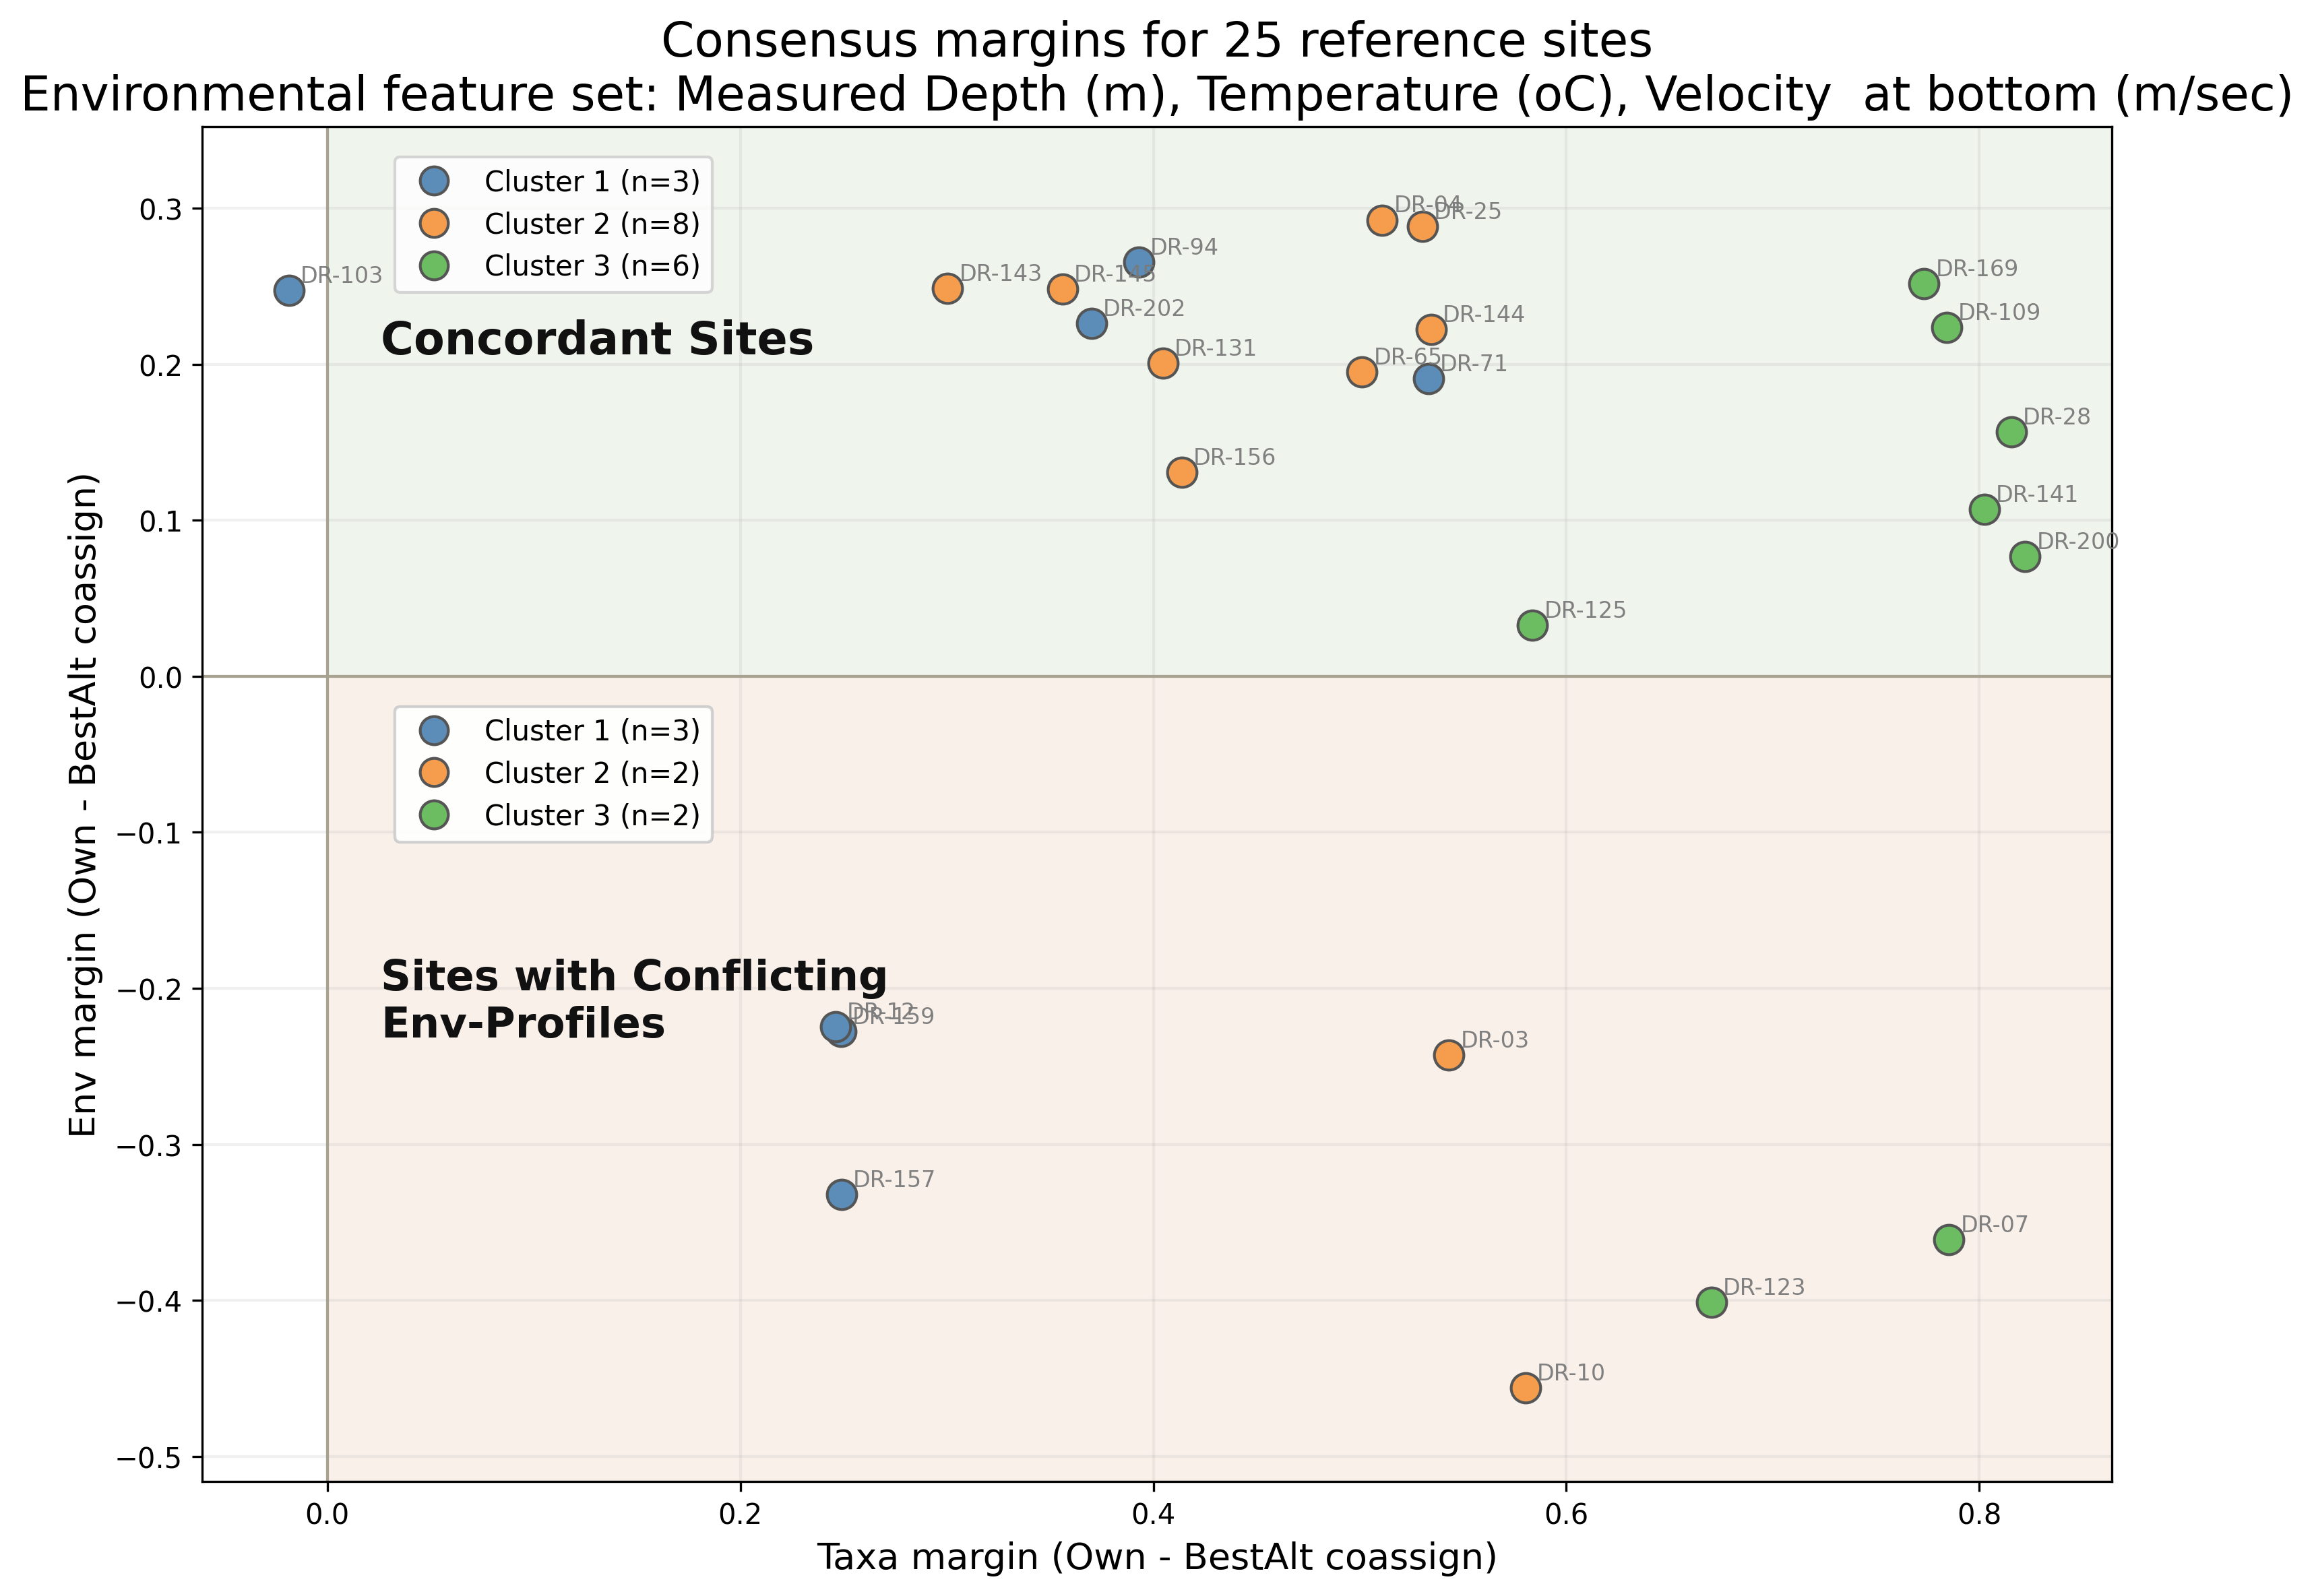

In [69]:
scatter_title = (
    f"Consensus margins for {M_REFERENCE} reference sites\n"
    f"Environmental feature set: {', '.join(retained_environment_features)}"
    )
margin_scatter_figure, margin_scatter_axis = render_concordance_margin_scatter(
    concordance_margin_table,
    id_col=SITE_ID_COLUMN,
    cluster_col=CLUSTER_LABEL_COLUMN,
    taxa_margin_col="taxa margin",
    environmental_margin_col="environmental margin",
    title=scatter_title,
    )
# save the margin scatter figure into figures folder
plt.savefig(FIGURE_DIR / "ch3_fw2_concordance_margin_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(margin_scatter_figure)

# Execution summary

After a complete corridor-case run, this notebook produces:

```text
../artifacts/A4_refsites_concordance_margins.xlsx
../figures/ch3_fw2_concordance_margin_scatter.png
```

When `STUDY_CASE = "DR"`, the same output filenames are written under:

```text
../DetroitRiverCase/results/
../DetroitRiverCase/artifacts/
../DetroitRiverCase/figures/
```